# Lecture 6 — Distributions (Python converted)

This notebook is a Python conversion of the original R script for Lecture 6.

In [ ]:
# Imports and plotting setup
import numpy as np
import pandas as pd
import matplotlib.pyplot as plt
from scipy import stats

In [3]:
# --- Distribution functions (binomial examples)
# Probability of exactly 50 successes when flipping a fair coin 100 times
stats.binom.pmf(50, 100, 0.5)

np.float64(0.07958923738717875)

In [4]:
# Probability of exactly 51 successes
stats.binom.pmf(51, 100, 0.5)

np.float64(0.07802866410507722)

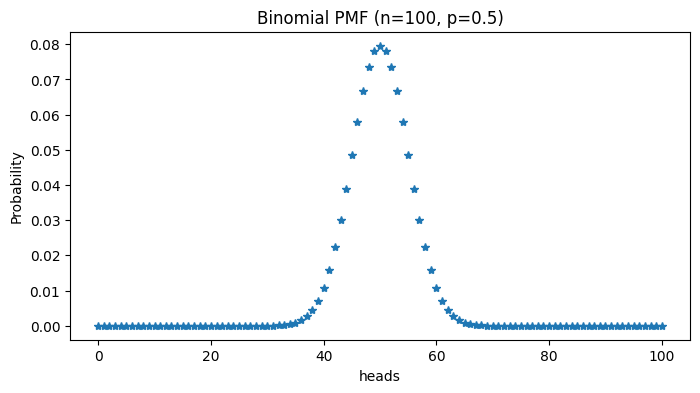

In [5]:
# Plot pmf for 0..100
x = np.arange(0, 101)
y = stats.binom.pmf(x, 100, 0.5)
plt.figure(figsize=(8,4))
plt.plot(x, y, marker='*', linestyle='None')
plt.xlabel('heads')
plt.ylabel('Probability')
plt.title('Binomial PMF (n=100, p=0.5)')
plt.show()

In [6]:
# Probability of at least 50 successes (CDF)
1 - stats.binom.cdf(49, 100, 0.5)  # P(X>=50)


np.float64(0.5397946186935889)

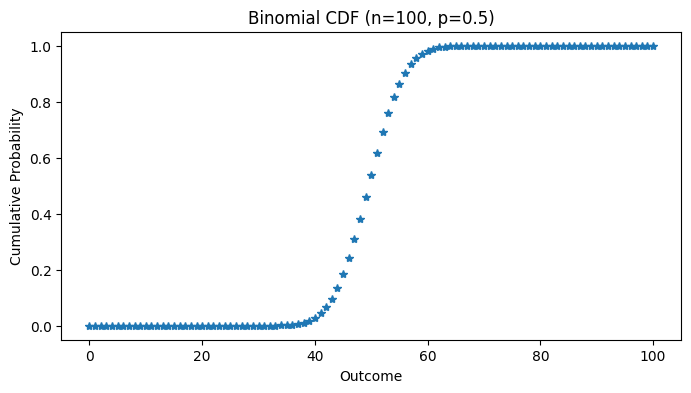

In [7]:
# Cumulative plot
y_cdf = stats.binom.cdf(x, 100, 0.5)
plt.figure(figsize=(8,4))
plt.plot(x, y_cdf, marker='*', linestyle='None')
plt.xlabel('Outcome')
plt.ylabel('Cumulative Probability')
plt.title('Binomial CDF (n=100, p=0.5)')
plt.show()


In [8]:
# 95th percentile (quantile)
stats.binom.ppf(0.95, 100, 0.5)


np.float64(58.0)

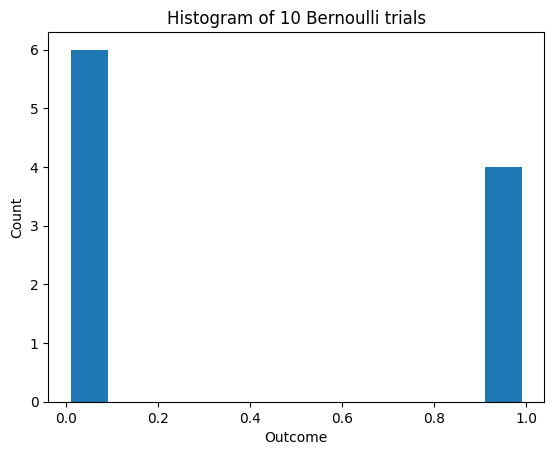

In [10]:
# Generate 10 random draws from Bernoulli(0.5) (n=1 binomial) and histogram
samples = stats.binom.rvs(1, 0.5, size=10)
plt.figure()
plt.hist(samples, bins=np.arange(0,1.1,0.1), rwidth=0.8)
plt.xlabel('Outcome')
plt.ylabel('Count')
plt.title('Histogram of 10 Bernoulli trials')
plt.show()

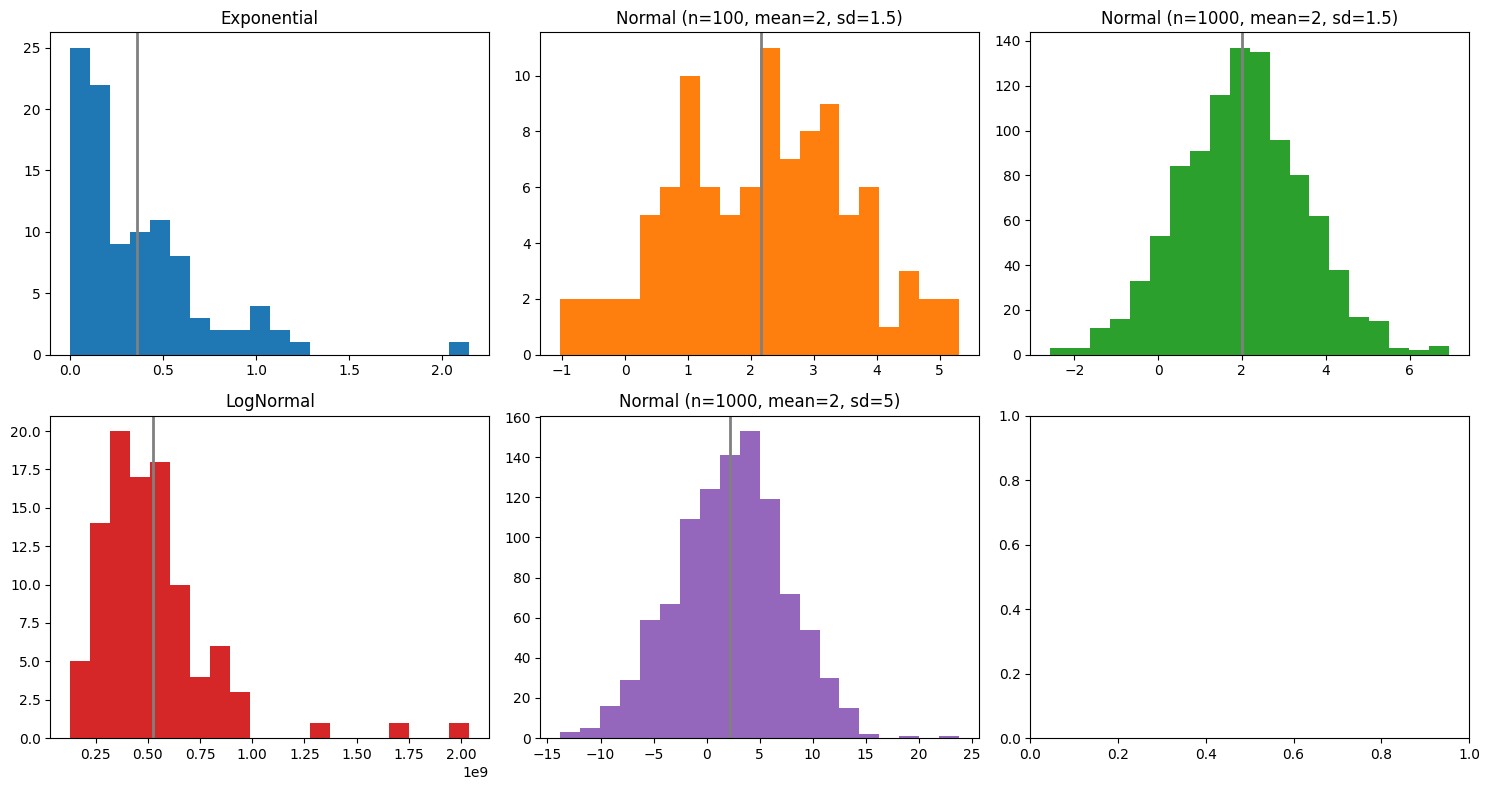

In [20]:
# --- Skewness and kurtosis examples (generate distributions)
rng = np.random.default_rng()
Expo = rng.exponential(scale=1/3, size=100)            # rate=3 -> scale=1/3
LogNorm = rng.lognormal(mean=20, sigma=0.5, size=100)   # meanlog=20, sdlog=0.5
Norman = rng.normal(loc=2, scale=1.5, size=100)
Norman2 = rng.normal(loc=2, scale=1.5, size=1000)
Norman3 = rng.normal(loc=2, scale=5, size=1000)

# Histograms with mean lines
fig, axes = plt.subplots(2, 3, figsize=(15,8))
axes[0,0].hist(Expo, bins=20, color='C0')
axes[0,0].axvline(Expo.mean(), color='grey', linewidth=2)
axes[0,0].set_title('Exponential')

axes[0,1].hist(Norman, bins=20, color='C1')
axes[0,1].axvline(Norman.mean(), color='grey', linewidth=2)
axes[0,1].set_title('Normal (n=100, mean=2, sd=1.5)')

axes[0,2].hist(Norman2, bins=20, color='C2')
axes[0,2].axvline(Norman2.mean(), color='grey', linewidth=2)
axes[0,2].set_title('Normal (n=1000, mean=2, sd=1.5)')

# Lognormal and wider normal
axes[1,0].hist(LogNorm, bins=20, color='C3')
axes[1,0].axvline(LogNorm.mean(), color='grey', linewidth=2)
axes[1,0].set_title('LogNormal')

axes[1,1].hist(Norman3, bins=20, color='C4')
axes[1,1].axvline(Norman3.mean(), color='grey', linewidth=2)
axes[1,1].set_title('Normal (n=1000, mean=2, sd=5)')

plt.tight_layout()
plt.show()

In [23]:
# --- Skewness, kurtosis, and normality tests
from scipy.stats import skew, kurtosis, shapiro, kstest

print('Skewness:')
print('Expo', skew(Expo))
print('LogNorm', skew(LogNorm))
print('Norman', skew(Norman))
print('Norman2', skew(Norman2))
print('Norman3', skew(Norman3))

print('Kurtosis (Pearson):')
print('Expo', kurtosis(Expo, fisher=False))
print('LogNorm', kurtosis(LogNorm, fisher=False))
print('Norman', kurtosis(Norman, fisher=False))
print('Norman2', kurtosis(Norman2, fisher=False))
print('Norman3', kurtosis(Norman3, fisher=False))

# Shapiro-Wilk tests
print('Shapiro-Wilk tests:')
print('Expo', shapiro(Expo))
print('LogNorm', shapiro(LogNorm))
print('Norman', shapiro(Norman))
print('Norman2', shapiro(Norman2))
print('Norman3', shapiro(Norman3))

# Kolmogorov-Smirnov tests against a normal with sample mean and sd
print('Kolmogorov-Smirnov tests (vs normal with sample mean/sd):')
print('Expo', kstest(Expo, 'norm', args=(Expo.mean(), Expo.std(ddof=0))))
print('LogNorm', kstest(LogNorm, 'norm', args=(LogNorm.mean(), LogNorm.std(ddof=0))))
print('Norman', kstest(Norman, 'norm', args=(Norman.mean(), Norman.std(ddof=0))))
print('Norman2', kstest(Norman2, 'norm', args=(Norman2.mean(), Norman2.std(ddof=0))))
print('Norman3', kstest(Norman3, 'norm', args=(Norman3.mean(), Norman3.std(ddof=0))))

Skewness:
Expo 1.9609031940547825
LogNorm 2.510290061148373
Norman -0.029799682828959027
Norman2 0.04268189945576376
Norman3 -0.013618706710794003
Kurtosis (Pearson):
Expo 8.664876679373922
LogNorm 12.666978387913545
Norman 2.4159713685033255
Norman2 3.1257394446421833
Norman3 3.0655439567367613
Shapiro-Wilk tests:
Expo ShapiroResult(statistic=np.float64(0.8098992706421003), pvalue=np.float64(5.044137474928574e-10))
LogNorm ShapiroResult(statistic=np.float64(0.7962477028694331), pvalue=np.float64(1.902141283682018e-10))
Norman ShapiroResult(statistic=np.float64(0.9899246723413316), pvalue=np.float64(0.658503738694892))
Norman2 ShapiroResult(statistic=np.float64(0.9988224184541387), pvalue=np.float64(0.76934206463094))
Norman3 ShapiroResult(statistic=np.float64(0.9983457882991085), pvalue=np.float64(0.45820452015227564))
Kolmogorov-Smirnov tests (vs normal with sample mean/sd):
Expo KstestResult(statistic=np.float64(0.1603180023404856), pvalue=np.float64(0.01032667550622845), statistic_